In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from scipy.stats import (zscore,skew,kurtosis,pearsonr,spearmanr,ttest_ind,chi2_contingency,f_oneway,norm)
from numpy.linalg import det, eig

In [3]:
df = pd.read_excel('Trip_Analysis.xlsx')

print(df.head())

   Trip_Distance  Fare_Amount Ride_Category  Surge_Multiplier  \
0              8   270.569350        Shared               2.5   
1             21   275.161032       Economy               2.5   
2             16   359.748971       Economy               2.0   
3             12   264.044264       Premium               1.5   
4              9   225.256916        Shared               2.0   

   Customer_Rating Ride_Time  
0                3  Non-Peak  
1                3  Non-Peak  
2                5  Non-Peak  
3                5  Non-Peak  
4                2  Non-Peak  


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Trip_Distance     200 non-null    int64  
 1   Fare_Amount       200 non-null    float64
 2   Ride_Category     200 non-null    str    
 3   Surge_Multiplier  200 non-null    float64
 4   Customer_Rating   200 non-null    int64  
 5   Ride_Time         200 non-null    str    
dtypes: float64(2), int64(2), str(2)
memory usage: 9.5 KB
None


In [5]:
print(df.shape)

(200, 6)


#Data Cleaning

In [6]:
print(df.isnull().sum())

Trip_Distance       0
Fare_Amount         0
Ride_Category       0
Surge_Multiplier    0
Customer_Rating     0
Ride_Time           0
dtype: int64


In [7]:
df = df.drop_duplicates()

In [8]:
print(df.dtypes)

Trip_Distance         int64
Fare_Amount         float64
Ride_Category           str
Surge_Multiplier    float64
Customer_Rating       int64
Ride_Time               str
dtype: object


#Handle Missing Values

In [9]:
df = pd.read_excel('Trip_Analysis.xlsx')

numeric_cols = ['Trip_Distance','Fare_Amount','Surge_Multiplier','Customer_Rating']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Trip_Distance       0
Fare_Amount         0
Ride_Category       0
Surge_Multiplier    0
Customer_Rating     0
Ride_Time           0
dtype: int64


#1 Linear Algebra Concepts

Vector Representation

In [10]:
ride_vector = np.array([8, 270.56, 2.5, 3])
print(ride_vector)

[  8.   270.56   2.5    3.  ]


Matrix Representation

In [11]:
matrix_data = df[['Trip_Distance', 'Fare_Amount',
                  'Surge_Multiplier', 'Customer_Rating']].values

print(matrix_data[:5])

[[  8.         270.5693496    2.5          3.        ]
 [ 21.         275.16103167   2.5          3.        ]
 [ 16.         359.74897068   2.           5.        ]
 [ 12.         264.04426352   1.5          5.        ]
 [  9.         225.25691628   2.           2.        ]]


Determinant

In [12]:
sample_matrix = matrix_data[:4]

print(det(sample_matrix))

6170.898359916611


Eigenvalues and Eigenvectors

In [13]:
cov_matrix = np.cov(matrix_data.T)

eigenvalues, eigenvectors = eig(cov_matrix)

print('Eigenvalues:', eigenvalues)
print('Eigenvectors:', eigenvectors)

Eigenvalues: [6.19468069e+03 7.11214818e+01 2.06461916e+00 3.00480581e-01]
Eigenvectors: [[ 1.82233395e-03  9.99884035e-01 -1.50965382e-02 -8.31205977e-04]
 [ 9.99997864e-01 -1.80767212e-03  9.92413592e-04 -1.37686365e-04]
 [ 1.21498632e-04  1.10732109e-03  1.83053823e-02  9.99831822e-01]
 [ 9.67397451e-04 -1.50805647e-02 -9.99717972e-01  1.83198821e-02]]


2 Probability concepts

Basic Probability

In [14]:
peak_prob = len(df[df['Ride_Time'] == 'Peak']) / len(df)

print('Probability of Peak Ride:', peak_prob)

Probability of Peak Ride: 0.515


Conditional Probability

In [16]:
premium_peak = len(df[(df['Ride_Category'] == 'Premium') & (df['Ride_Time'] == 'Peak')])

peak_total = len(df[df['Ride_Time'] == 'Peak'])

conditional_prob = premium_peak / peak_total

print(conditional_prob)

0.3106796116504854


Bayes' Theorem

In [17]:
P_peak = len(df[df['Ride_Time'] == 'Peak']) / len(df)

P_premium_given_peak = premium_peak / len(df[df['Ride_Time'] == 'Peak'])

P_premium = len(df[df['Ride_Category'] == 'Premium']) / len(df)

bayes = (P_premium_given_peak * P_peak) / P_premium

print(bayes)

0.5517241379310346


Probability Distribution

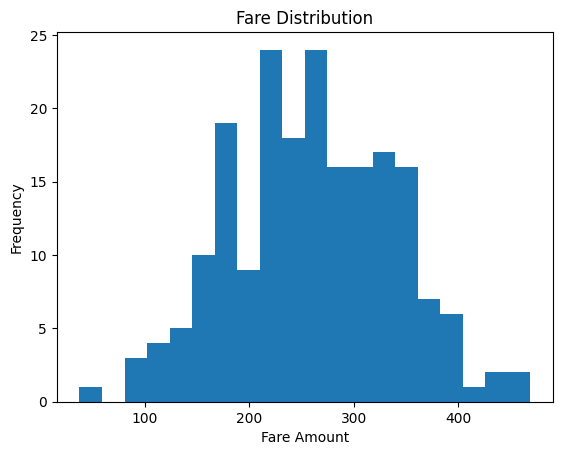

In [18]:
plt.hist(df['Fare_Amount'], bins=20)
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Fare Distribution')
plt.show()

#3 Descriptive Statistics - (Mean, Median, Mode, Variance, tandard Deviation,Skewness, Kurtosis)

In [19]:
print(df.mean(numeric_only=True))

Trip_Distance        15.640000
Fare_Amount         260.312376
Surge_Multiplier      1.677500
Customer_Rating       2.930000
dtype: float64


In [20]:
print(df.median(numeric_only=True))

Trip_Distance        15.000000
Fare_Amount         256.907103
Surge_Multiplier      1.500000
Customer_Rating       3.000000
dtype: float64


In [21]:
print(df.mode())

     Trip_Distance  Fare_Amount Ride_Category  Surge_Multiplier  \
0             29.0    37.585916       Economy               1.0   
1              NaN    88.214805           NaN               NaN   
2              NaN    90.403074           NaN               NaN   
3              NaN    98.209841           NaN               NaN   
4              NaN   106.920280           NaN               NaN   
..             ...          ...           ...               ...   
195            NaN   418.905411           NaN               NaN   
196            NaN   437.839754           NaN               NaN   
197            NaN   441.122877           NaN               NaN   
198            NaN   453.133017           NaN               NaN   
199            NaN   468.753773           NaN               NaN   

     Customer_Rating Ride_Time  
0                1.0      Peak  
1                NaN       NaN  
2                NaN       NaN  
3                NaN       NaN  
4                NaN       NaN

In [22]:
print(df.var(numeric_only=True))

Trip_Distance         71.126030
Fare_Amount         6194.654468
Surge_Multiplier       0.301250
Customer_Rating        2.085528
dtype: float64


In [23]:
print(df.std(numeric_only=True))

Trip_Distance        8.433625
Fare_Amount         78.706127
Surge_Multiplier     0.548862
Customer_Rating      1.444136
dtype: float64


In [24]:
print(df.skew(numeric_only=True))

Trip_Distance       0.052817
Fare_Amount         0.022837
Surge_Multiplier    0.156067
Customer_Rating     0.062733
dtype: float64


In [25]:
print(df.kurtosis(numeric_only=True))

Trip_Distance      -1.270149
Fare_Amount        -0.251430
Surge_Multiplier   -1.295399
Customer_Rating    -1.323724
dtype: float64


4 Outlier Detection (Percentiles,quartiles, IQR, Z-score)

In [26]:
print(np.percentile(df['Fare_Amount'], [25, 50, 75]))

[208.5288261  256.90710336 319.76378248]


In [27]:
Q1 = df['Fare_Amount'].quantile(0.25)
Q3 = df['Fare_Amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare_Amount'] < lower) |
              (df['Fare_Amount'] > upper)]

print(outliers)

    Trip_Distance  Fare_Amount Ride_Category  Surge_Multiplier  \
10             12    37.585916       Economy               1.0   

    Customer_Rating Ride_Time  
10                5  Non-Peak  


In [28]:
z_scores = np.abs(zscore(df['Fare_Amount']))

outliers_z = df[z_scores > 3]

print(outliers_z)

Empty DataFrame
Columns: [Trip_Distance, Fare_Amount, Ride_Category, Surge_Multiplier, Customer_Rating, Ride_Time]
Index: []


In [29]:
df['Fare_Amount'] = pd.to_numeric(df['Fare_Amount'],errors='coerce')

df['Fare_Amount'] = df['Fare_Amount'].fillna(df['Fare_Amount'].median())

z_scores = np.abs(zscore(df['Fare_Amount']))

outliers_z = df[z_scores > 2]

print(outliers_z)

     Trip_Distance  Fare_Amount Ride_Category  Surge_Multiplier  \
10              12    37.585916       Economy               1.0   
17               4    88.214805       Economy               1.0   
63              22   453.133017        Shared               1.0   
94              16   468.753773        Shared               2.0   
150              6   441.122877        Shared               1.5   
180             21    90.403074       Premium               2.5   
187             12   437.839754        Shared               2.5   
194             29    98.209841       Premium               2.0   
197             14   418.905411       Premium               1.5   

     Customer_Rating Ride_Time  
10                 5  Non-Peak  
17                 5  Non-Peak  
63                 3      Peak  
94                 4  Non-Peak  
150                4  Non-Peak  
180                2  Non-Peak  
187                4  Non-Peak  
194                1      Peak  
197                5  Non-Peak  

5 Relationship Measurement - (Pearson, Spearman, and covariance)

In [31]:
corr, p = pearsonr(df['Trip_Distance'],
                   df['Fare_Amount'])

print('Pearson Correlation:', corr)

Pearson Correlation: 0.016813110993310926


In [32]:
corr, p = spearmanr(df['Trip_Distance'],
                    df['Fare_Amount'])

print('Spearman Correlation:', corr)

Spearman Correlation: 0.02342713443070998


In [33]:
covariance = np.cov(df['Trip_Distance'],
                    df['Fare_Amount'])

print(covariance)

[[  71.12603015   11.16017252]
 [  11.16017252 6194.65446811]]


6 Inferential Statistics (bootstrapping, CLT, point & interval estimation)

In [34]:
sample_means = []

for i in range(1000):
    sample = df['Fare_Amount'].sample(frac=1, replace=True)
    sample_means.append(sample.mean())

print(np.mean(sample_means))

260.29904768508607


In [35]:
point_estimate = df['Fare_Amount'].mean()

print(point_estimate)

260.31237600443757


In [36]:
mean = df['Fare_Amount'].mean()
std = df['Fare_Amount'].std()
n = len(df)

margin = 1.96 * (std / np.sqrt(n))

lower = mean - margin
upper = mean + margin

print(lower, upper)

249.40426328850282 271.2204887203723


7 Hypothesis Testing -(z-test, t-test, chi-square, F-test, ANOVA, A/B testing)

In [37]:
sample_mean = df['Fare_Amount'].mean()
pop_mean = 300
std = df['Fare_Amount'].std()
n = len(df)

z = (sample_mean - pop_mean) / (std / np.sqrt(n))

print(z)

-7.131182547982732


In [38]:
peak = df[df['Ride_Time'] == 'Peak']['Fare_Amount']
non_peak = df[df['Ride_Time'] == 'Non-Peak']['Fare_Amount']

stat, p = ttest_ind(peak, non_peak)

print('T-statistic:', stat)
print('P-value:', p)

T-statistic: -0.598515832956693
P-value: 0.5501798656873053


In [39]:
contingency = pd.crosstab(df['Ride_Category'],
                          df['Ride_Time'])

chi2, p, dof, expected = chi2_contingency(contingency)

print('P-value:', p)

P-value: 0.4768642146833866


In [40]:
peak_var = np.var(peak, ddof=1)
non_peak_var = np.var(non_peak, ddof=1)

f = peak_var / non_peak_var

print(f)

0.7980003886968828


In [41]:
economy = df[df['Ride_Category'] == 'Economy']['Fare_Amount']
premium = df[df['Ride_Category'] == 'Premium']['Fare_Amount']
shared = df[df['Ride_Category'] == 'Shared']['Fare_Amount']

f_stat, p = f_oneway(economy, premium, shared)

print('F-statistic:', f_stat)
print('P-value:', p)

F-statistic: 0.9284988792342405
P-value: 0.3968686165946839


In [42]:
group_a = df[df['Surge_Multiplier'] == 1]['Fare_Amount']
group_b = df[df['Surge_Multiplier'] > 1]['Fare_Amount']

stat, p = ttest_ind(group_a, group_b)

print('P-value:', p)

P-value: 0.921920153507304


Visualization

Correlation Heatmap

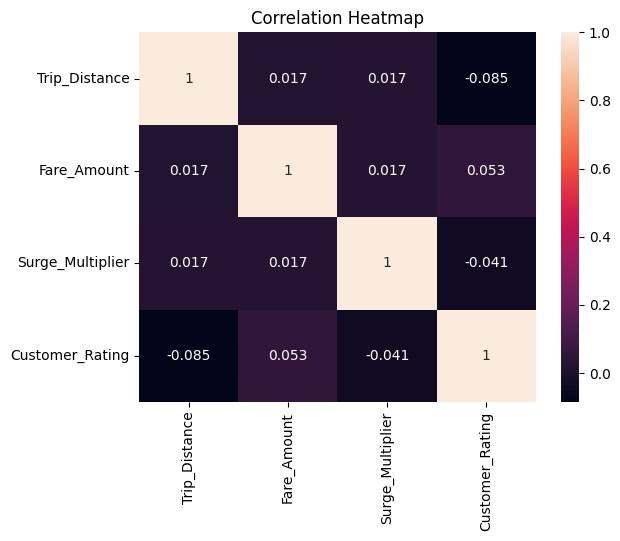

In [43]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

Boxplot for Outliers

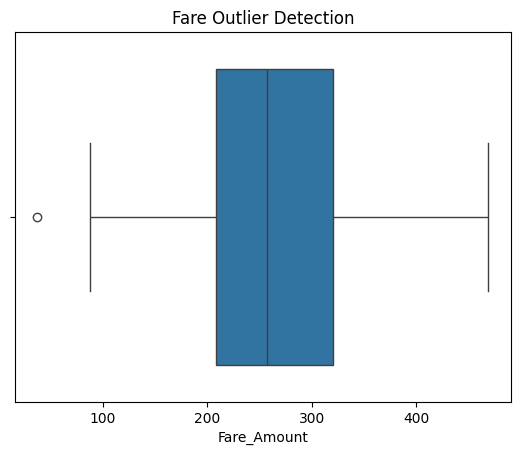

In [44]:
sns.boxplot(x=df['Fare_Amount'])
plt.title('Fare Outlier Detection')
plt.show()

Peak vs Non-Peak Fare Comparison

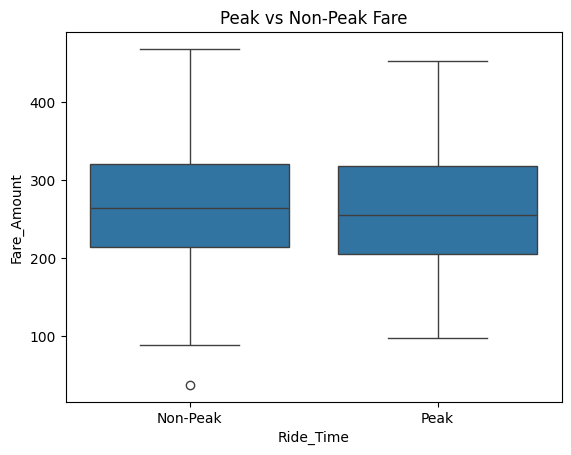

In [45]:
sns.boxplot(x='Ride_Time', y='Fare_Amount', data=df)
plt.title('Peak vs Non-Peak Fare')
plt.show()

Data Analysis

1 Does trip distance significantly affect fare amount?

In [46]:
corr, p = pearsonr(df['Trip_Distance'],
                   df['Fare_Amount'])

print("Pearson Correlation:", corr)
print("P-value:", p)

Pearson Correlation: 0.016813110993310926
P-value: 0.8132001771984607


In [47]:
covariance = np.cov(df['Trip_Distance'],
                    df['Fare_Amount'])

print(covariance)

[[  71.12603015   11.16017252]
 [  11.16017252 6194.65446811]]


2 Are premium rides statistically more expensive than economy rides

In [48]:
df.groupby('Ride_Category')['Fare_Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Ride_Category,,,,,,,,
Economy,82.0,257.748443,75.104118,37.585916,214.900111,259.137700,312.085805,399.760454
Premium,58.0,252.455037,76.611336,90.403074,198.146388,250.897986,308.622634,418.905411
Shared,60.0,271.411845,85.349101,129.938529,209.700796,260.743938,345.785051,468.753773


In [49]:
premium = df[df['Ride_Category']=='Premium']['Fare_Amount']
economy = df[df['Ride_Category']=='Economy']['Fare_Amount']

stat, p = ttest_ind(premium, economy)  #p < 0.05 Significant difference ; p > 0.05 - No significant difference

print("T-statistic:", stat)
print("P-value:", p)

T-statistic: -0.4074012822247926
P-value: 0.6843445588292055


3 Relationship Between Surge Pricing and Customer Ratings

In [50]:
corr, p = spearmanr(df['Surge_Multiplier'], df['Customer_Rating'])

#Positive correlation - Ratings increase with surge & Negative correlation - Ratings decrease with surge
print("Spearman Correlation:", corr)
print("P-value:", p)

Spearman Correlation: -0.04709083768799108
P-value: 0.5078698477562072


4 Peak-Hour vs Non-Peak Revenue

In [51]:
peak = df[df['Ride_Time']=='Peak']['Fare_Amount']

non_peak = df[df['Ride_Time']=='Non-Peak']['Fare_Amount']

stat, p = ttest_ind(peak, non_peak)  #p < 0.05 = peak-hour revenue differs significantly.

print("P-value:", p)

P-value: 0.5501798656873053


5 Detect Unusual Fare Values

In [52]:
Q1 = df['Fare_Amount'].quantile(0.25)
Q3 = df['Fare_Amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare_Amount'] < lower) |
              (df['Fare_Amount'] > upper)]

print(outliers)

    Trip_Distance  Fare_Amount Ride_Category  Surge_Multiplier  \
10             12    37.585916       Economy               1.0   

    Customer_Rating Ride_Time  
10                5  Non-Peak  


In [53]:
z_scores = np.abs(zscore(df['Fare_Amount']))

outliers_z = df[z_scores > 3]

print(outliers_z)

Empty DataFrame
Columns: [Trip_Distance, Fare_Amount, Ride_Category, Surge_Multiplier, Customer_Rating, Ride_Time]
Index: []


In [54]:
print(np.percentile(df['Fare_Amount'],
                    [1,5,25,50,75,95,99]))

[ 90.38119159 137.3530339  208.5288261  256.90710336 319.76378248
 383.08535134 441.242978  ]


6 Ride Demand Probabilities

In [55]:
premium_prob = len(df[df['Ride_Category']=='Premium']) / len(df)

print(premium_prob)

0.29


In [56]:
premium_peak = len(df[
    (df['Ride_Category']=='Premium') &
    (df['Ride_Time']=='Peak')
])

peak_total = len(df[df['Ride_Time']=='Peak'])

conditional_prob = premium_peak / peak_total

print(conditional_prob)

0.3106796116504854


In [57]:
P_peak = len(df[df['Ride_Time']=='Peak']) / len(df)

P_premium_given_peak = premium_peak / len(
    df[df['Ride_Time']=='Peak']
)

P_premium = len(
    df[df['Ride_Category']=='Premium']
) / len(df)

bayes = (P_premium_given_peak * P_peak) / P_premium

print(bayes)

0.5517241379310346


7 Operational Factors Related to Business Performance

In [58]:
numeric_df = df.select_dtypes(
    include=['int64','float64']
)

print(numeric_df.corr())

                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance          1.000000     0.016813          0.017131   
Fare_Amount            0.016813     1.000000          0.017419   
Surge_Multiplier       0.017131     0.017419          1.000000   
Customer_Rating       -0.084599     0.052723         -0.041304   

                  Customer_Rating  
Trip_Distance           -0.084599  
Fare_Amount              0.052723  
Surge_Multiplier        -0.041304  
Customer_Rating          1.000000  


In [59]:
print(numeric_df.corr(method='spearman'))

                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance          1.000000     0.023427          0.025459   
Fare_Amount            0.023427     1.000000          0.011764   
Surge_Multiplier       0.025459     0.011764          1.000000   
Customer_Rating       -0.082067     0.047499         -0.047091   

                  Customer_Rating  
Trip_Distance           -0.082067  
Fare_Amount              0.047499  
Surge_Multiplier        -0.047091  
Customer_Rating          1.000000  


In [60]:
print(numeric_df.cov())

                  Trip_Distance  Fare_Amount  Surge_Multiplier  \
Trip_Distance         71.126030    11.160173          0.079296   
Fare_Amount           11.160173  6194.654468          0.752497   
Surge_Multiplier       0.079296     0.752497          0.301250   
Customer_Rating       -1.030352     5.992595         -0.032739   

                  Customer_Rating  
Trip_Distance           -1.030352  
Fare_Amount              5.992595  
Surge_Multiplier        -0.032739  
Customer_Rating          2.085528  


In [61]:
cov_matrix = np.cov(numeric_df.T)

eigenvalues, eigenvectors = eig(cov_matrix)

print("Eigenvalues:", eigenvalues)

print("Eigenvectors:")
print(eigenvectors)

Eigenvalues: [6.19468069e+03 7.11214818e+01 2.06461916e+00 3.00480581e-01]
Eigenvectors:
[[ 1.82233395e-03  9.99884035e-01 -1.50965382e-02 -8.31205977e-04]
 [ 9.99997864e-01 -1.80767212e-03  9.92413592e-04 -1.37686365e-04]
 [ 1.21498632e-04  1.10732109e-03  1.83053823e-02  9.99831822e-01]
 [ 9.67397451e-04 -1.50805647e-02 -9.99717972e-01  1.83198821e-02]]


8 Statistical Evidence for Pricing Improvements

In [62]:
mean = df['Fare_Amount'].mean()

std = df['Fare_Amount'].std()

n = len(df)

margin = 1.96 * (std / np.sqrt(n))

lower = mean - margin
upper = mean + margin

print(lower, upper)

249.40426328850282 271.2204887203723


In [63]:
sample_means = []

for i in range(1000):

    sample = df['Fare_Amount'].sample(
        frac=1,
        replace=True
    )

    sample_means.append(sample.mean())

print(np.mean(sample_means))

260.50346188800125
